# Système Intelligent de Prédiction du Risque de Diabète
**Université Numérique Cheikh Hamidou Kane (UN-CHK)**  
**Macoumba Touré | macoumba.toure@unchk.edu.sn** 

**MASTER IL – Ingénierie Logicielle | Examen Systèmes Intelligents**  
**Tuteur : M. Abdourahmane BALDE | Année 2025–2026**

---

## 📦 Importation des bibliothèques

In [1]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import matplotlib.gridspec as gridspec
import warnings
warnings.filterwarnings('ignore')

# Scikit-learn
from sklearn.model_selection import train_test_split, cross_val_score
from sklearn.preprocessing import StandardScaler
from sklearn.linear_model import LogisticRegression
from sklearn.neighbors import KNeighborsClassifier
from sklearn.tree import DecisionTreeClassifier
from sklearn.ensemble import RandomForestClassifier
from sklearn.svm import SVC
from sklearn.neural_network import MLPClassifier
from sklearn.metrics import (
    accuracy_score, precision_score, recall_score,
    f1_score, confusion_matrix, classification_report
)

print('✅ Toutes les bibliothèques importées avec succès!')

✅ Toutes les bibliothèques importées avec succès!


---
# PARTIE 1 : Analyse Exploratoire des Données (EDA)

## A. Chargement et Inspection

In [2]:
# Chargement du dataset
# Option 1 : depuis un fichier local
# df = pd.read_csv('diabetes.csv')

# Option 2 : téléchargement direct via URL
url = 'https://raw.githubusercontent.com/jbrownlee/Datasets/master/pima-indians-diabetes.data.csv'
columns = ['Pregnancies','Glucose','BloodPressure','SkinThickness',
           'Insulin','BMI','DiabetesPedigreeFunction','Age','Outcome']
df = pd.read_csv(url, header=None, names=columns)

print('✅ Dataset chargé avec succès!')
print(f'Dimensions : {df.shape[0]} lignes x {df.shape[1]} colonnes')

✅ Dataset chargé avec succès!
Dimensions : 768 lignes x 9 colonnes


In [3]:
# Affichage des 5 premières lignes
print('=== 5 premières lignes ===')
df.head()

=== 5 premières lignes ===


,Pregnancies,Glucose,BloodPressure,SkinThickness,Insulin,BMI,DiabetesPedigreeFunction,Age,Outcome
0,6,148,72,35,0,33.6,0.627,50,1
1,1,85,66,29,0,26.6,0.351,31,0
2,8,183,64,0,0,23.3,0.672,32,1
3,1,89,66,23,94,28.1,0.167,21,0
4,0,137,40,35,168,43.1,2.288,33,1


In [4]:
# Types des variables
print('=== Types des variables ===')
print(df.dtypes)
print()
print('=== Informations générales ===')
df.info()

=== Types des variables ===
Pregnancies                   int64
Glucose                       int64
BloodPressure                 int64
SkinThickness                 int64
Insulin                       int64
BMI                         float64
DiabetesPedigreeFunction    float64
Age                           int64
Outcome                       int64
dtype: object

=== Informations générales ===
<class 'pandas.DataFrame'>
RangeIndex: 768 entries, 0 to 767
Data columns (total 9 columns):
 #   Column                    Non-Null Count  Dtype  
---  ------                    --------------  -----  
 0   Pregnancies               768 non-null    int64  
 1   Glucose                   768 non-null    int64  
 2   BloodPressure             768 non-null    int64  
 3   SkinThickness             768 non-null    int64  
 4   Insulin                   768 non-null    int64  
 5   BMI                       768 non-null    float64
 6   DiabetesPedigreeFunction  768 non-null    float64
 7   Age      

In [5]:
# Statistiques descriptives
print('=== Statistiques descriptives ===')
df.describe().round(2)

=== Statistiques descriptives ===


,Pregnancies,Glucose,BloodPressure,SkinThickness,Insulin,BMI,DiabetesPedigreeFunction,Age,Outcome
count,768.00,768.00,768.00,768.00,768.00,768.00,768.00,768.00,768.00
mean,3.85,120.89,69.11,20.54,79.80,31.99,0.47,33.24,0.35
std,3.37,31.97,19.36,15.95,115.24,7.88,0.33,11.76,0.48
min,0.00,0.00,0.00,0.00,0.00,0.00,0.08,21.00,0.00
25%,1.00,99.00,62.00,0.00,0.00,27.30,0.24,24.00,0.00
50%,3.00,117.00,72.00,23.00,30.50,32.00,0.37,29.00,0.00
75%,6.00,140.25,80.00,32.00,127.25,36.60,0.63,41.00,1.00
max,17.00,199.00,122.00,99.00,846.00,67.10,2.42,81.00,1.00


In [6]:
# Distribution de la variable cible
print('=== Distribution de la variable cible (Outcome) ===')
outcome_counts = df['Outcome'].value_counts()
print(outcome_counts)
print(f'\nProportion diabétiques : {outcome_counts[1]/len(df)*100:.1f}%')
print(f'Proportion non-diabétiques : {outcome_counts[0]/len(df)*100:.1f}%')

=== Distribution de la variable cible (Outcome) ===
Outcome
0    500
1    268
Name: count, dtype: int64

Proportion diabétiques : 34.9%
Proportion non-diabétiques : 65.1%


## B. Analyse des Valeurs Manquantes / Incohérentes

In [7]:
# Vérification des valeurs nulles explicites
print('=== Valeurs nulles (NaN) ===')
print(df.isnull().sum())

# Les colonnes où 0 est biologiquement impossible
zero_cols = ['Glucose', 'BloodPressure', 'SkinThickness', 'Insulin', 'BMI']

print('\n=== Valeurs 0 incohérentes (biologiquement impossibles) ===')
for col in zero_cols:
    n_zeros = (df[col] == 0).sum()
    pct = n_zeros / len(df) * 100
    print(f'{col:30s}: {n_zeros:3d} zéros ({pct:.1f}%)')

=== Valeurs nulles (NaN) ===
Pregnancies                 0
Glucose                     0
BloodPressure               0
SkinThickness               0
Insulin                     0
BMI                         0
DiabetesPedigreeFunction    0
Age                         0
Outcome                     0
dtype: int64

=== Valeurs 0 incohérentes (biologiquement impossibles) ===
Glucose                       :   5 zéros (0.7%)
BloodPressure                 :  35 zéros (4.6%)
SkinThickness                 : 227 zéros (29.6%)
Insulin                       : 374 zéros (48.7%)
BMI                           :  11 zéros (1.4%)


In [8]:
# Stratégie : remplacer les 0 par la médiane de chaque groupe (diabétique / non-diabétique)
df_clean = df.copy()

for col in zero_cols:
    # Remplacer 0 par NaN
    df_clean[col] = df_clean[col].replace(0, np.nan)
    # Imputer par la médiane selon le groupe Outcome
    df_clean[col] = df_clean.groupby('Outcome')[col].transform(
        lambda x: x.fillna(x.median())
    )

print('✅ Valeurs incohérentes remplacées par la médiane par groupe.')
print('Vérification (plus de 0 pour les colonnes biologiques) :')
for col in zero_cols:
    print(f'  {col}: {(df_clean[col] == 0).sum()} zéros restants')

✅ Valeurs incohérentes remplacées par la médiane par groupe.
Vérification (plus de 0 pour les colonnes biologiques) :
  Glucose: 0 zéros restants
  BloodPressure: 0 zéros restants
  SkinThickness: 0 zéros restants
  Insulin: 0 zéros restants
  BMI: 0 zéros restants


## C. Analyse Statistique (NumPy)

In [9]:
# Calcul avec NumPy
features = [c for c in df_clean.columns if c != 'Outcome']

print(f'{'Variable':<30} {'Moyenne':>10} {'Médiane':>10} {'Variance':>12}')
print('-' * 65)
for col in features:
    arr = df_clean[col].values
    mean   = np.mean(arr)
    median = np.median(arr)
    var    = np.var(arr)
    print(f'{col:<30} {mean:>10.2f} {median:>10.2f} {var:>12.2f}')

Variable                          Moyenne    Médiane     Variance
-----------------------------------------------------------------
Pregnancies                          3.85       3.00        11.34
Glucose                            121.68     117.00       926.86
BloodPressure                       72.39      72.00       146.37
SkinThickness                       29.09      28.00        78.94
Insulin                            141.75     102.50      7928.62
BMI                                 32.43      32.05        47.28
DiabetesPedigreeFunction             0.47       0.37         0.11
Age                                 33.24      29.00       138.12


In [10]:
# Matrice de corrélation (calcul NumPy)
corr_matrix = np.corrcoef(df_clean[features + ['Outcome']].values.T)
corr_df = pd.DataFrame(corr_matrix, columns=features+['Outcome'], index=features+['Outcome'])

print('=== Corrélation avec Outcome ===')
corr_outcome = corr_df['Outcome'].drop('Outcome').sort_values(ascending=False)
print(corr_outcome.round(3))

=== Corrélation avec Outcome ===
Glucose                     0.496
Insulin                     0.377
BMI                         0.316
SkinThickness               0.295
Age                         0.238
Pregnancies                 0.222
BloodPressure               0.174
DiabetesPedigreeFunction    0.174
Name: Outcome, dtype: float64


## D. Visualisations (Matplotlib)

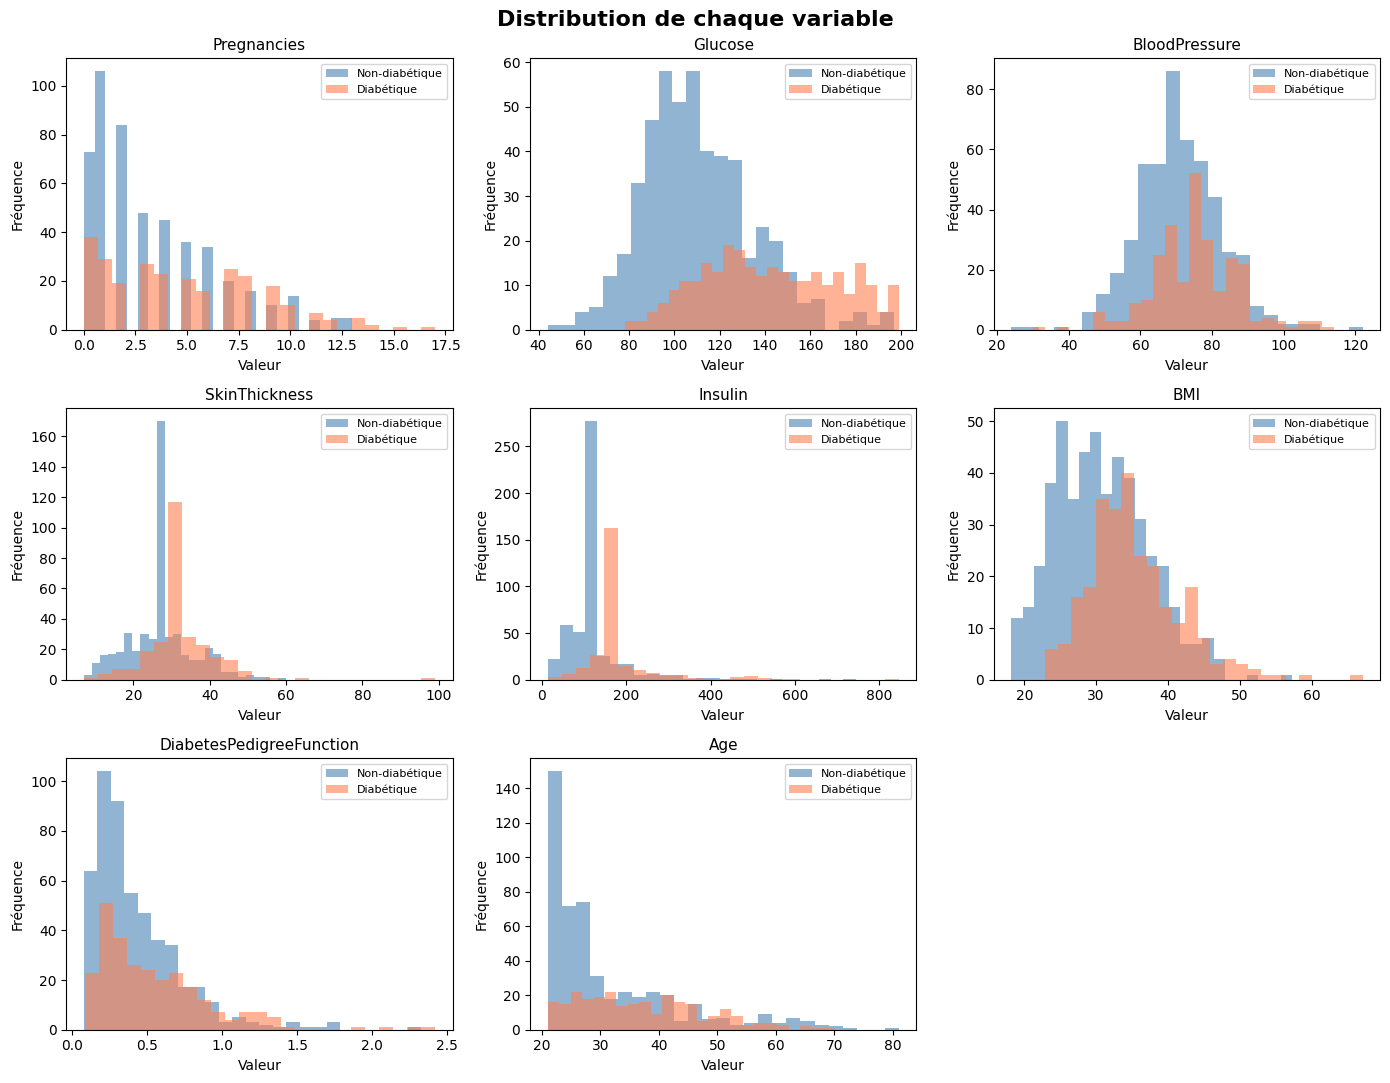

✅ Histogrammes sauvegardés.


In [11]:
# --- Histogrammes ---
fig, axes = plt.subplots(3, 3, figsize=(14, 11))
fig.suptitle('Distribution de chaque variable', fontsize=16, fontweight='bold')

colors = ['steelblue', 'coral', 'mediumseagreen', 'orchid',
          'goldenrod', 'tomato', 'slateblue', 'teal']

for i, col in enumerate(features):
    ax = axes[i//3][i%3]
    ax.hist(df_clean[df_clean['Outcome']==0][col], bins=25, alpha=0.6,
            color='steelblue', label='Non-diabétique')
    ax.hist(df_clean[df_clean['Outcome']==1][col], bins=25, alpha=0.6,
            color='coral', label='Diabétique')
    ax.set_title(col, fontsize=11)
    ax.set_xlabel('Valeur')
    ax.set_ylabel('Fréquence')
    ax.legend(fontsize=8)

# Case vide
axes[2][2].axis('off')
plt.tight_layout()
plt.savefig('histogrammes.png', dpi=120, bbox_inches='tight')
plt.show()
print('✅ Histogrammes sauvegardés.')

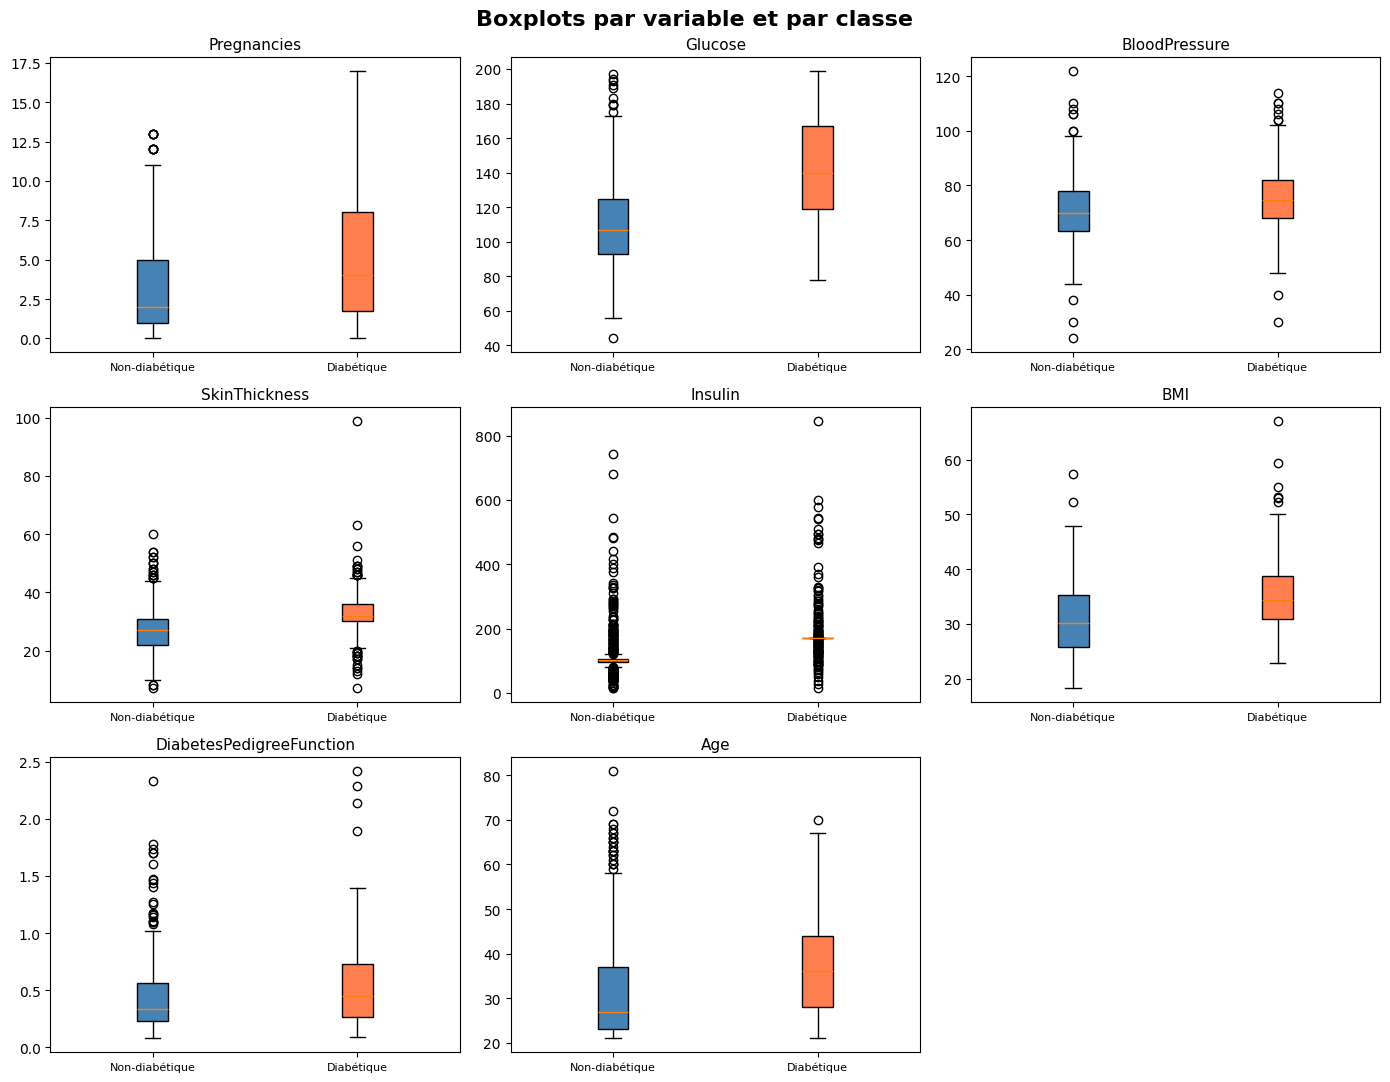

✅ Boxplots sauvegardés.


In [12]:
# --- Boxplots ---
fig, axes = plt.subplots(3, 3, figsize=(14, 11))
fig.suptitle('Boxplots par variable et par classe', fontsize=16, fontweight='bold')

for i, col in enumerate(features):
    ax = axes[i//3][i%3]
    data_to_plot = [df_clean[df_clean['Outcome']==0][col].values,
                    df_clean[df_clean['Outcome']==1][col].values]
    bp = ax.boxplot(data_to_plot, patch_artist=True,
                    labels=['Non-diabétique', 'Diabétique'])
    bp['boxes'][0].set_facecolor('steelblue')
    bp['boxes'][1].set_facecolor('coral')
    ax.set_title(col, fontsize=11)
    ax.tick_params(axis='x', labelsize=8)

axes[2][2].axis('off')
plt.tight_layout()
plt.savefig('boxplots.png', dpi=120, bbox_inches='tight')
plt.show()
print('✅ Boxplots sauvegardés.')

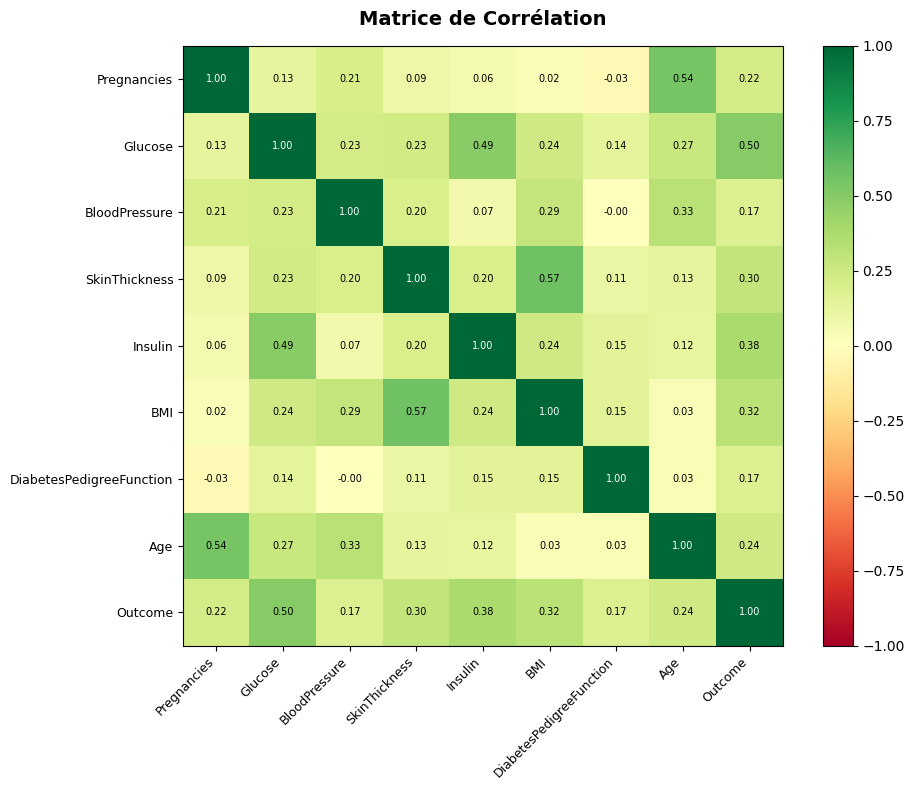

✅ Matrice de corrélation sauvegardée.


In [13]:
# --- Matrice de corrélation (heatmap Matplotlib) ---
all_cols = features + ['Outcome']
corr = df_clean[all_cols].corr().values

fig, ax = plt.subplots(figsize=(10, 8))
im = ax.imshow(corr, cmap='RdYlGn', vmin=-1, vmax=1)
plt.colorbar(im, ax=ax)

ax.set_xticks(range(len(all_cols)))
ax.set_yticks(range(len(all_cols)))
ax.set_xticklabels(all_cols, rotation=45, ha='right', fontsize=9)
ax.set_yticklabels(all_cols, fontsize=9)
ax.set_title('Matrice de Corrélation', fontsize=14, fontweight='bold', pad=15)

for i in range(len(all_cols)):
    for j in range(len(all_cols)):
        ax.text(j, i, f'{corr[i,j]:.2f}',
                ha='center', va='center', fontsize=7,
                color='black' if abs(corr[i,j]) < 0.7 else 'white')

plt.tight_layout()
plt.savefig('correlation_matrix.png', dpi=120, bbox_inches='tight')
plt.show()
print('✅ Matrice de corrélation sauvegardée.')

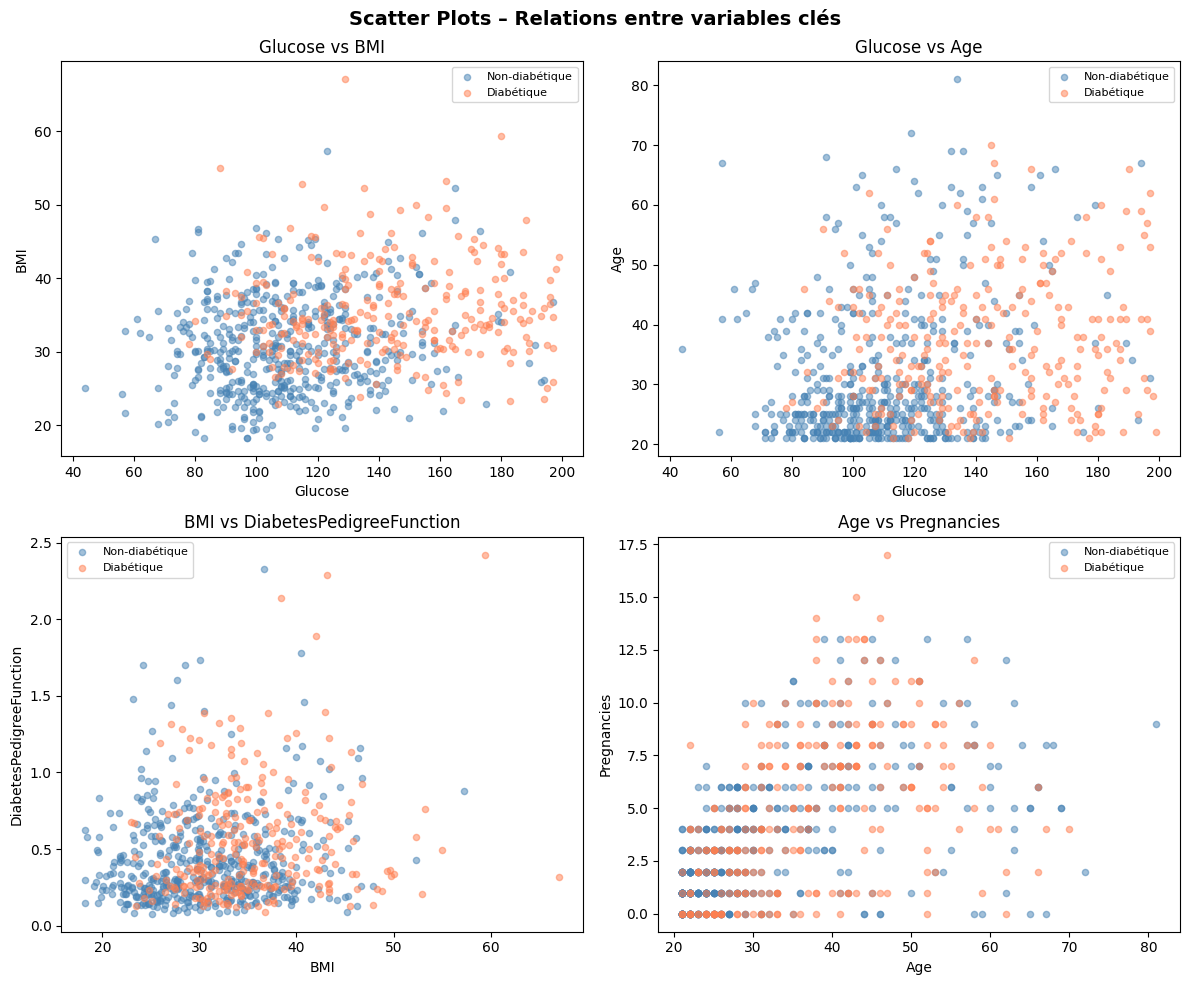

✅ Scatter plots sauvegardés.


In [14]:
# --- Scatter plots pertinents ---
scatter_pairs = [
    ('Glucose', 'BMI'),
    ('Glucose', 'Age'),
    ('BMI', 'DiabetesPedigreeFunction'),
    ('Age', 'Pregnancies')
]

fig, axes = plt.subplots(2, 2, figsize=(12, 10))
fig.suptitle('Scatter Plots – Relations entre variables clés', fontsize=14, fontweight='bold')

for idx, (x_col, y_col) in enumerate(scatter_pairs):
    ax = axes[idx//2][idx%2]
    for outcome, color, label in [(0,'steelblue','Non-diabétique'), (1,'coral','Diabétique')]:
        mask = df_clean['Outcome'] == outcome
        ax.scatter(df_clean[mask][x_col], df_clean[mask][y_col],
                   alpha=0.5, c=color, label=label, s=20)
    ax.set_xlabel(x_col)
    ax.set_ylabel(y_col)
    ax.set_title(f'{x_col} vs {y_col}')
    ax.legend(fontsize=8)

plt.tight_layout()
plt.savefig('scatter_plots.png', dpi=120, bbox_inches='tight')
plt.show()
print('✅ Scatter plots sauvegardés.')

---
# PARTIE 2 : Prétraitement des Données

In [15]:
# --- Gestion des valeurs aberrantes (méthode IQR) ---
df_processed = df_clean.copy()

print('=== Détection des outliers (méthode IQR) ===')
for col in features:
    Q1 = df_processed[col].quantile(0.25)
    Q3 = df_processed[col].quantile(0.75)
    IQR = Q3 - Q1
    lower = Q1 - 1.5 * IQR
    upper = Q3 + 1.5 * IQR
    n_out = ((df_processed[col] < lower) | (df_processed[col] > upper)).sum()
    # Clipping (winsorisation) : cap à la borne au lieu de supprimer
    df_processed[col] = df_processed[col].clip(lower, upper)
    print(f'{col:<30}: {n_out:3d} outliers traités (clipping)')

print(f'\nDimensions après traitement : {df_processed.shape}')

=== Détection des outliers (méthode IQR) ===
Pregnancies                   :   4 outliers traités (clipping)
Glucose                       :   0 outliers traités (clipping)
BloodPressure                 :  14 outliers traités (clipping)
SkinThickness                 :  87 outliers traités (clipping)
Insulin                       :  51 outliers traités (clipping)
BMI                           :   8 outliers traités (clipping)
DiabetesPedigreeFunction      :  29 outliers traités (clipping)
Age                           :   9 outliers traités (clipping)

Dimensions après traitement : (768, 9)


In [16]:
# --- Séparation Features / Target ---
X = df_processed[features].values
y = df_processed['Outcome'].values

# --- Split Train / Test (80% / 20%, stratifié) ---
X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.20, random_state=42, stratify=y
)

print(f'Train : {X_train.shape[0]} échantillons')
print(f'Test  : {X_test.shape[0]} échantillons')
print(f'Distribution train – 0:{(y_train==0).sum()} | 1:{(y_train==1).sum()}')
print(f'Distribution test  – 0:{(y_test==0).sum()}  | 1:{(y_test==1).sum()}')

Train : 614 échantillons
Test  : 154 échantillons
Distribution train – 0:400 | 1:214
Distribution test  – 0:100  | 1:54


In [17]:
# --- Standardisation (StandardScaler) ---
# Justification : la plupart des algorithmes (KNN, SVM, ANN, LR) sont sensibles à l'échelle.
# Le scaler est fit UNIQUEMENT sur le train set pour éviter le data leakage.

scaler = StandardScaler()
X_train_sc = scaler.fit_transform(X_train)   # fit + transform sur train
X_test_sc  = scaler.transform(X_test)        # transform uniquement sur test

print('✅ Standardisation appliquée.')
print(f'Moyenne train (après scaling) : {X_train_sc.mean(axis=0).round(4)}')
print(f'Std    train (après scaling)  : {X_train_sc.std(axis=0).round(4)}')

✅ Standardisation appliquée.
Moyenne train (après scaling) : [-0. -0. -0.  0. -0.  0.  0.  0.]
Std    train (après scaling)  : [1. 1. 1. 1. 1. 1. 1. 1.]


---
# PARTIE 3 : Modélisation

### Modèle 1 – Régression Logistique

**Principe théorique :** La régression logistique modélise la probabilité d'appartenir à une classe via la fonction sigmoïde. Elle cherche les poids w tels que P(y=1|x) = σ(wᵀx + b). C'est un modèle linéaire, rapide, interprétable.

In [18]:
lr_model = LogisticRegression(max_iter=1000, random_state=42)
lr_model.fit(X_train_sc, y_train)
lr_pred = lr_model.predict(X_test_sc)
print('✅ Régression Logistique – entraînée et prédictions effectuées.')

✅ Régression Logistique – entraînée et prédictions effectuées.


### Modèle 2 – K-Nearest Neighbors (KNN)

**Principe théorique :** KNN classe un point en regardant les k voisins les plus proches dans l'espace des features (distance euclidienne). Pas de phase d'entraînement explicite (lazy learner). Sensible à l'échelle → nécessite la standardisation.

In [19]:
knn_model = KNeighborsClassifier(n_neighbors=7)
knn_model.fit(X_train_sc, y_train)
knn_pred = knn_model.predict(X_test_sc)
print('✅ KNN – entraîné et prédictions effectuées.')

✅ KNN – entraîné et prédictions effectuées.


### Modèle 3 – Arbre de Décision

**Principe théorique :** L'arbre de décision partitionne récursivement l'espace des features selon des règles if-else qui maximisent la pureté des nœuds (Gini ou entropie). Très interprétable mais peut overfitter.

In [20]:
dt_model = DecisionTreeClassifier(max_depth=5, random_state=42)
dt_model.fit(X_train_sc, y_train)
dt_pred = dt_model.predict(X_test_sc)
print('✅ Arbre de Décision – entraîné et prédictions effectuées.')

✅ Arbre de Décision – entraîné et prédictions effectuées.


### Modèle 4 – Random Forest

**Principe théorique :** Ensemble de N arbres de décision entraînés sur des sous-ensembles bootstrap des données (bagging) et avec sélection aléatoire des features à chaque split. La prédiction finale est le vote majoritaire. Réduit l'overfitting.

In [21]:
rf_model = RandomForestClassifier(n_estimators=100, max_depth=6, random_state=42)
rf_model.fit(X_train_sc, y_train)
rf_pred = rf_model.predict(X_test_sc)
print('✅ Random Forest – entraîné et prédictions effectuées.')

✅ Random Forest – entraîné et prédictions effectuées.


### Modèle 5 – SVM (Support Vector Machine)

**Principe théorique :** SVM cherche l'hyperplan séparateur qui maximise la marge entre les classes. Le kernel RBF permet de gérer des données non linéairement séparables via une projection dans un espace de dimension supérieure.

In [22]:
svm_model = SVC(kernel='rbf', C=1.0, gamma='scale', random_state=42)
svm_model.fit(X_train_sc, y_train)
svm_pred = svm_model.predict(X_test_sc)
print('✅ SVM – entraîné et prédictions effectuées.')

✅ SVM – entraîné et prédictions effectuées.


### Modèle 6 – Réseau de Neurones Artificiels (ANN / MLP)

**Principe théorique :** Un MLP (Multi-Layer Perceptron) est un réseau de neurones avec une couche d'entrée, des couches cachées (avec activation non-linéaire ReLU) et une couche de sortie softmax/sigmoïde. L'apprentissage se fait par rétropropagation du gradient.

In [23]:
ann_model = MLPClassifier(hidden_layer_sizes=(64, 32), activation='relu',
                          max_iter=500, random_state=42, early_stopping=True,
                          validation_fraction=0.1)
ann_model.fit(X_train_sc, y_train)
ann_pred = ann_model.predict(X_test_sc)
print('✅ ANN (MLP) – entraîné et prédictions effectuées.')

✅ ANN (MLP) – entraîné et prédictions effectuées.


---
# PARTIE 4 : Évaluation des Performances

In [24]:
# Fonction d'évaluation
def evaluate_model(name, y_true, y_pred):
    acc  = accuracy_score(y_true, y_pred)
    prec = precision_score(y_true, y_pred, zero_division=0)
    rec  = recall_score(y_true, y_pred, zero_division=0)
    f1   = f1_score(y_true, y_pred, zero_division=0)
    return {'Modèle': name, 'Accuracy': acc, 'Precision': prec, 'Recall': rec, 'F1-Score': f1}

# Collecte des résultats
results = []
models_info = [
    ('Logistic Regression', lr_pred),
    ('KNN (k=7)',            knn_pred),
    ('Decision Tree',        dt_pred),
    ('Random Forest',        rf_pred),
    ('SVM (RBF)',            svm_pred),
    ('ANN (MLP)',            ann_pred),
]

for name, preds in models_info:
    results.append(evaluate_model(name, y_test, preds))

results_df = pd.DataFrame(results).set_index('Modèle')
print('=== Tableau comparatif des performances ===')
results_df.round(4)

=== Tableau comparatif des performances ===


,Accuracy,Precision,Recall,F1-Score
Modèle,,,,
Logistic Regression,0.7532,0.6481,0.6481,0.6481
KNN (k=7),0.8377,0.7636,0.7778,0.7706
Decision Tree,0.8247,0.7547,0.7407,0.7477
Random Forest,0.8636,0.8113,0.7963,0.8037
SVM (RBF),0.8442,0.7778,0.7778,0.7778
ANN (MLP),0.8052,0.7308,0.7037,0.7170


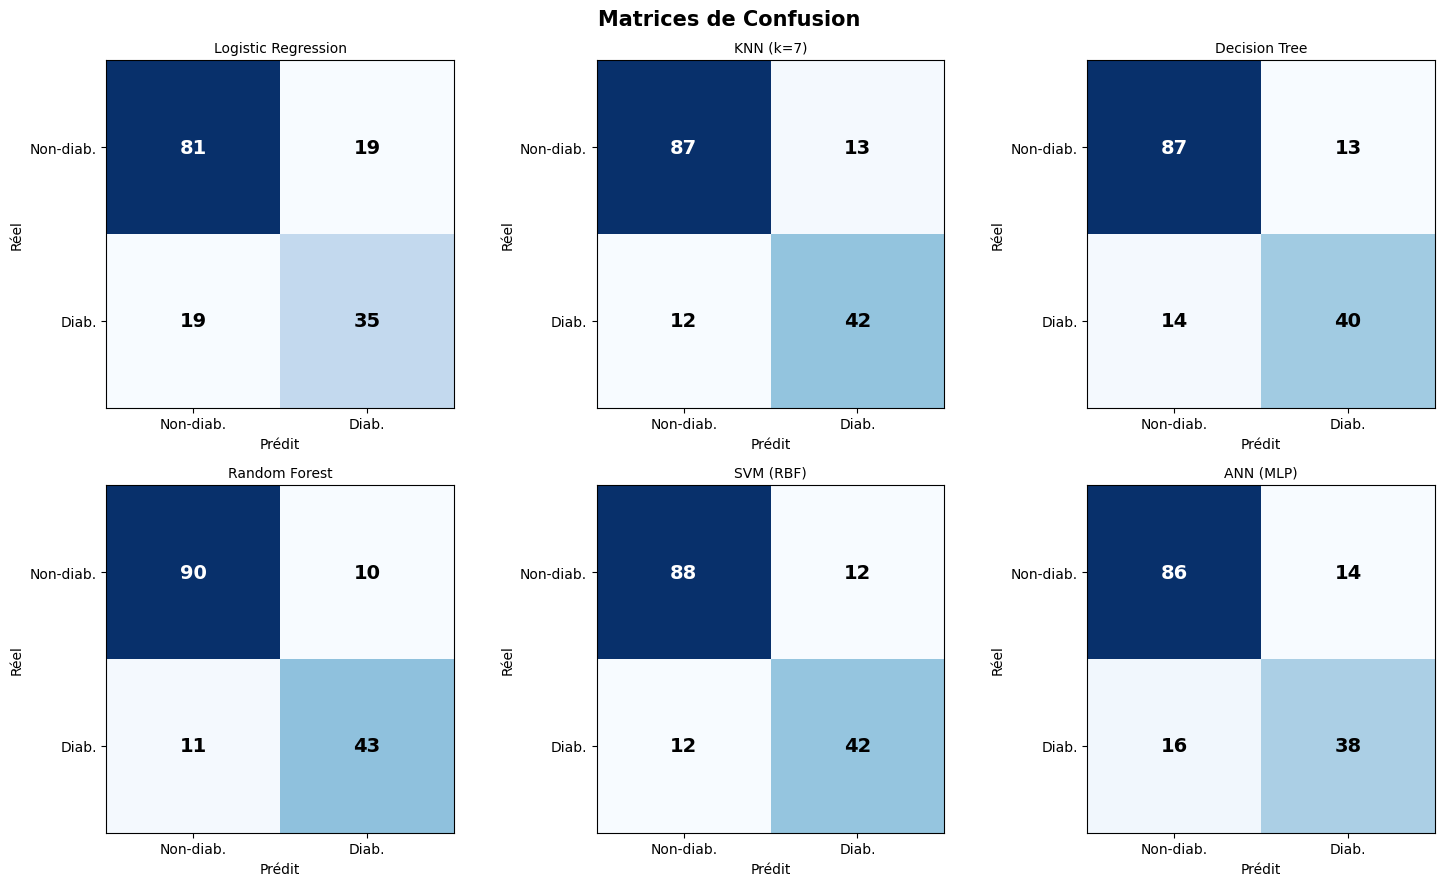

✅ Matrices de confusion sauvegardées.


In [25]:
# --- Matrices de confusion ---
fig, axes = plt.subplots(2, 3, figsize=(15, 9))
fig.suptitle('Matrices de Confusion', fontsize=15, fontweight='bold')

for idx, (name, preds) in enumerate(models_info):
    ax = axes[idx//3][idx%3]
    cm = confusion_matrix(y_test, preds)
    im = ax.imshow(cm, cmap='Blues')
    ax.set_title(name, fontsize=10)
    ax.set_xlabel('Prédit')
    ax.set_ylabel('Réel')
    ax.set_xticks([0,1])
    ax.set_yticks([0,1])
    ax.set_xticklabels(['Non-diab.', 'Diab.'])
    ax.set_yticklabels(['Non-diab.', 'Diab.'])
    for i in range(2):
        for j in range(2):
            ax.text(j, i, str(cm[i,j]), ha='center', va='center',
                    fontsize=14, fontweight='bold',
                    color='white' if cm[i,j] > cm.max()/2 else 'black')

plt.tight_layout()
plt.savefig('confusion_matrices.png', dpi=120, bbox_inches='tight')
plt.show()
print('✅ Matrices de confusion sauvegardées.')

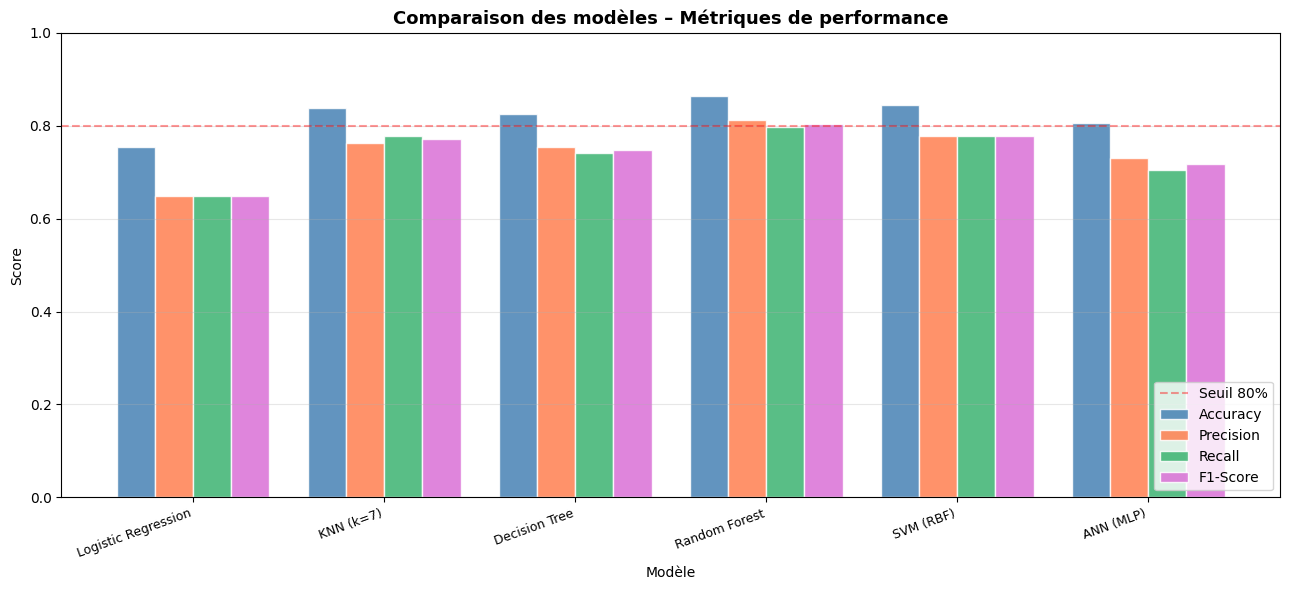

✅ Graphique de comparaison sauvegardé.


In [26]:
# --- Graphique de comparaison des modèles ---
metrics = ['Accuracy', 'Precision', 'Recall', 'F1-Score']
x = np.arange(len(results_df))
width = 0.2
colors_bar = ['steelblue', 'coral', 'mediumseagreen', 'orchid']

fig, ax = plt.subplots(figsize=(13, 6))
for i, (metric, color) in enumerate(zip(metrics, colors_bar)):
    bars = ax.bar(x + i*width, results_df[metric], width=width,
                  label=metric, color=color, alpha=0.85, edgecolor='white')

ax.set_xlabel('Modèle')
ax.set_ylabel('Score')
ax.set_title('Comparaison des modèles – Métriques de performance', fontsize=13, fontweight='bold')
ax.set_xticks(x + width*1.5)
ax.set_xticklabels(results_df.index, rotation=20, ha='right', fontsize=9)
ax.set_ylim(0, 1.0)
ax.axhline(0.8, color='red', linestyle='--', alpha=0.4, label='Seuil 80%')
ax.legend(loc='lower right')
ax.grid(axis='y', alpha=0.3)

plt.tight_layout()
plt.savefig('model_comparison.png', dpi=120, bbox_inches='tight')
plt.show()
print('✅ Graphique de comparaison sauvegardé.')

In [27]:
# --- Identification du meilleur modèle ---
best_model = results_df['F1-Score'].idxmax()
best_f1    = results_df['F1-Score'].max()
print(f'🏆 Meilleur modèle (F1-Score) : {best_model} → F1 = {best_f1:.4f}')
print()

# Analyse obligatoire
print('=== Analyse obligatoire ===')
n0, n1 = (y==0).sum(), (y==1).sum()
print(f'1. Équilibre du dataset :')
print(f'   Non-diabétiques : {n0} ({n0/len(y)*100:.1f}%)')
print(f'   Diabétiques     : {n1} ({n1/len(y)*100:.1f}%)')
print(f'   → Dataset DÉSÉQUILIBRÉ (ratio ~{n0/n1:.1f}:1). Les métriques Recall et F1 sont plus pertinentes qu\'Accuracy.')
print()
print(f'2. Erreur critique en contexte médical :')
print(f'   → Les FAUX NÉGATIFS (FN) sont les plus critiques : prédire "non-diabétique"')
print(f'     alors que le patient EST diabétique prive ce dernier d\'un traitement précoce.')
print(f'   → Le RECALL (sensibilité) est la métrique prioritaire à maximiser.')
print()
print(f'3. Fiabilité du modèle :')
print(f'   → Un modèle avec Accuracy ~80% sur 768 échantillons est LIMITÉ.')
print(f'   → Validation croisée recommandée, données supplémentaires et features enrichies.')

🏆 Meilleur modèle (F1-Score) : Random Forest → F1 = 0.8037

=== Analyse obligatoire ===
1. Équilibre du dataset :
   Non-diabétiques : 500 (65.1%)
   Diabétiques     : 268 (34.9%)
   → Dataset DÉSÉQUILIBRÉ (ratio ~1.9:1). Les métriques Recall et F1 sont plus pertinentes qu'Accuracy.

2. Erreur critique en contexte médical :
   → Les FAUX NÉGATIFS (FN) sont les plus critiques : prédire "non-diabétique"
     alors que le patient EST diabétique prive ce dernier d'un traitement précoce.
   → Le RECALL (sensibilité) est la métrique prioritaire à maximiser.

3. Fiabilité du modèle :
   → Un modèle avec Accuracy ~80% sur 768 échantillons est LIMITÉ.
   → Validation croisée recommandée, données supplémentaires et features enrichies.


In [28]:
# --- Validation croisée du meilleur modèle ---
best_estimators = {
    'Logistic Regression': lr_model,
    'KNN (k=7)':            knn_model,
    'Decision Tree':        dt_model,
    'Random Forest':        rf_model,
    'SVM (RBF)':            svm_model,
    'ANN (MLP)':            ann_model,
}

# Scalez toutes les données pour la CV
X_all_sc = scaler.transform(X)

print('=== Validation croisée (5-fold) – F1-Score ===')
for name, model in best_estimators.items():
    cv_scores = cross_val_score(model, X_all_sc, y, cv=5, scoring='f1')
    print(f'{name:<25}: {cv_scores.mean():.4f} ± {cv_scores.std():.4f}')

=== Validation croisée (5-fold) – F1-Score ===
Logistic Regression      : 0.6985 ± 0.0333
KNN (k=7)                : 0.7821 ± 0.0235
Decision Tree            : 0.8381 ± 0.0143
Random Forest            : 0.8350 ± 0.0369
SVM (RBF)                : 0.7855 ± 0.0245
ANN (MLP)                : 0.6775 ± 0.0661


---
# PARTIE 5 : Interprétation et Discussion

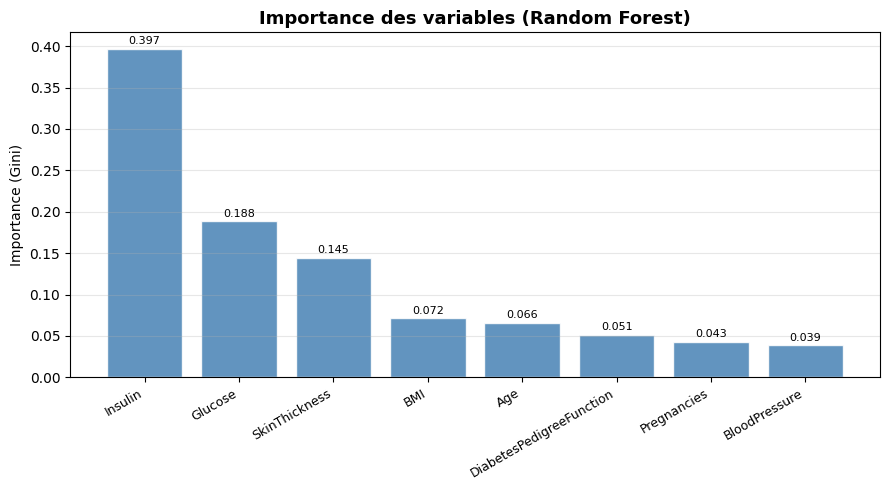

✅ Graphique importance des variables sauvegardé.


In [29]:
# --- Variables les plus influentes (Random Forest Feature Importances) ---
importances = rf_model.feature_importances_
sorted_idx = np.argsort(importances)[::-1]

fig, ax = plt.subplots(figsize=(9, 5))
bars = ax.bar(range(len(features)), importances[sorted_idx],
              color='steelblue', edgecolor='white', alpha=0.85)
ax.set_xticks(range(len(features)))
ax.set_xticklabels([features[i] for i in sorted_idx], rotation=30, ha='right', fontsize=9)
ax.set_ylabel('Importance (Gini)')
ax.set_title('Importance des variables (Random Forest)', fontsize=13, fontweight='bold')
ax.grid(axis='y', alpha=0.3)

for bar, val in zip(bars, importances[sorted_idx]):
    ax.text(bar.get_x() + bar.get_width()/2, bar.get_height() + 0.003,
            f'{val:.3f}', ha='center', va='bottom', fontsize=8)

plt.tight_layout()
plt.savefig('feature_importance.png', dpi=120, bbox_inches='tight')
plt.show()
print('✅ Graphique importance des variables sauvegardé.')

In [30]:
print('=== PARTIE 5 : Interprétation et Discussion ===')
print()
print('1. VARIABLES LES PLUS INFLUENTES')
print('   Les 3 variables les plus prédictives sont :')
for i in range(3):
    print(f'   - {features[sorted_idx[i]]}: {importances[sorted_idx[i]]:.3f}')
print('   → Glucose est la variable la plus discriminante, confirmant son rôle diagnostic.')
print()
print('2. LIMITES DES MODÈLES')
print('   - Dataset limité (768 obs.) → risque de variance élevée')
print('   - Pas de validation temporelle (les données ne sont pas datées)')
print('   - Variables cliniques imparfaites (valeurs aberrantes, encodage 0)')
print('   - ANN : risque d\'overfitting sans tuning extensif des hyperparamètres')
print()
print('3. AMÉLIORATIONS POSSIBLES')
print('   - Utiliser SMOTE pour rééquilibrer les classes')
print('   - GridSearchCV / RandomizedSearchCV pour l\'optimisation des hyperparamètres')
print('   - Enrichir les features (HbA1c, cholestérol, etc.)')
print('   - Ensemble methods : stacking ou voting')
print()
print('4. IMPLICATIONS ÉTHIQUES')
print('   - Un faux négatif peut retarder un traitement vital')
print('   - Biais potentiel : dataset issu uniquement de femmes amérindiennes Pima (> 21 ans)')
print('     → non généralisable à d\'autres populations sans validation externe')
print('   - Le modèle ne doit pas REMPLACER le médecin mais ASSISTER le diagnostic')
print('   - Transparence et explicabilité requises (droit à l\'explication – RGPD)')

=== PARTIE 5 : Interprétation et Discussion ===

1. VARIABLES LES PLUS INFLUENTES
   Les 3 variables les plus prédictives sont :
   - Insulin: 0.397
   - Glucose: 0.188
   - SkinThickness: 0.145
   → Glucose est la variable la plus discriminante, confirmant son rôle diagnostic.

2. LIMITES DES MODÈLES
   - Dataset limité (768 obs.) → risque de variance élevée
   - Pas de validation temporelle (les données ne sont pas datées)
   - Variables cliniques imparfaites (valeurs aberrantes, encodage 0)
   - ANN : risque d'overfitting sans tuning extensif des hyperparamètres

3. AMÉLIORATIONS POSSIBLES
   - Utiliser SMOTE pour rééquilibrer les classes
   - GridSearchCV / RandomizedSearchCV pour l'optimisation des hyperparamètres
   - Enrichir les features (HbA1c, cholestérol, etc.)
   - Ensemble methods : stacking ou voting

4. IMPLICATIONS ÉTHIQUES
   - Un faux négatif peut retarder un traitement vital
   - Biais potentiel : dataset issu uniquement de femmes amérindiennes Pima (> 21 ans)
     →

In [31]:
# --- Résumé final ---
print('\n' + '='*60)
print('RÉSUMÉ FINAL DU PROJET')
print('='*60)
print(results_df.round(4).to_string())
print()
print(f'🏆 Meilleur modèle : {best_model} (F1 = {best_f1:.4f})')
print('\n✅ Projet complété avec succès!')


RÉSUMÉ FINAL DU PROJET
                     Accuracy  Precision  Recall  F1-Score
Modèle                                                    
Logistic Regression    0.7532     0.6481  0.6481    0.6481
KNN (k=7)              0.8377     0.7636  0.7778    0.7706
Decision Tree          0.8247     0.7547  0.7407    0.7477
Random Forest          0.8636     0.8113  0.7963    0.8037
SVM (RBF)              0.8442     0.7778  0.7778    0.7778
ANN (MLP)              0.8052     0.7308  0.7037    0.7170

🏆 Meilleur modèle : Random Forest (F1 = 0.8037)

✅ Projet complété avec succès!
